In [1]:
import mujoco
import mujoco.viewer
import time
import mediapy as media
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sympy 
import scipy as sp
from scipy.signal import savgol_filter
import scipy.interpolate as sp_interp
from sympy.physics.vector import ReferenceFrame, dynamicsymbols
from scipy.optimize import approx_fprime

# Definición del sistema (Integracion del cuaderno: System_definition_project.ipynb)

In [2]:
#defino angulos
theta1, thetadot1, thetaddot1,theta2,thetadot2,thetaddot2=dynamicsymbols("theta_1 thetadot_1 thetaddot_1 theta_2 thetadot_2 thetaddot_2")

#defino variables del sistema
l0,l1,l2,m2,m3,I1,I2,i1,i2,t= sympy.symbols("L_0 L_1 L_2 m2 m3 I1 I2 i1 i2 t")
#parámetros del brazo en MuJoCo verificar con el codigo arm_project.ipynb
parameters2 = {l0 : 4.4/100,l1 : 2.6/100,i1 : l1/2,l2 : 2.3/100,i2 : l2/2,m2 : 4.601/1000,m3 : 2.330/1000,I1 : 5.176E-7,I2 : 1.879E-7}

# posición del centro de masa
#posición del centro de masa del primer eslabón
x_cb = i1 * sympy.sin(theta1)
y_cb = i1 * sympy.cos(theta1)

#posición del centro de masa del segundo eslabón
x_cc = l1 * sympy.sin(theta1) + i2 * sympy.sin(theta1 + theta2)
y_cc = l0 + l1 * sympy.cos(theta1) + i2 * sympy.cos(theta1 + theta2)

#velocidad del centro de masa
# primer eslabón
v_cb_x = sympy.diff(x_cb, t).subs({sympy.diff(theta1, t): thetadot1})
v_cb_y = sympy.diff(y_cb, t).subs({sympy.diff(theta1, t): thetadot1})
#velocidad del centro de masa del segundo eslabón
v_cc_x = sympy.diff(x_cc, t).subs({sympy.diff(theta1, t): thetadot1, sympy.diff(theta2, t): thetadot2})
v_cc_y = sympy.diff(y_cc, t).subs({sympy.diff(theta1, t): thetadot1, sympy.diff(theta2, t): thetadot2})
#aceleracion del centro de masa
# Primer eslabón
a_cb_x = sympy.diff(v_cb_x, t).subs({sympy.diff(theta1, t): thetadot1, sympy.diff(thetadot1, t): thetaddot1}).simplify()
a_cb_y = sympy.diff(v_cb_y, t).subs({sympy.diff(theta1, t): thetadot1, sympy.diff(thetadot1, t): thetaddot1}).simplify()
# Segundo eslabón
a_cc_x = sympy.diff(v_cc_x, t).subs({sympy.diff(theta1, t): thetadot1, sympy.diff(theta2, t): thetadot2, sympy.diff(thetadot1, t): thetaddot1, sympy.diff(thetadot2, t): thetaddot2}).simplify()
a_cc_y = sympy.diff(v_cc_y, t).subs({sympy.diff(theta1, t): thetadot1, sympy.diff(theta2, t): thetadot2, sympy.diff(thetadot1, t): thetaddot1, sympy.diff(thetadot2, t): thetaddot2}).simplify()

v_cb_sq = v_cb_x**2 + v_cb_y**2
v_cc_sq = v_cc_x**2 + v_cc_y**2

print("Velocidad del centro de masa del primer eslabón:")
display(sympy.Matrix([[v_cb_x], [v_cb_y]]))
print("Velocidad del centro de masa del segundo eslabón:")
display(sympy.Matrix([[v_cc_x], [v_cc_y]]))
print("Velocidad al cuadrado del centro de masa del primer eslabón:")
display(v_cb_sq)
print("Velocidad al cuadrado del centro de masa del segundo eslabón:")
display(v_cc_sq)
print("Aceleración del centro de masa del primer eslabón:")
display(sympy.Matrix([[a_cb_x], [a_cb_y]]))
print("Aceleración del centro de masa del segundo eslabón:")
display(sympy.Matrix([[a_cc_x], [a_cc_y]]))

a_cb_x = a_cb_x.subs(parameters2).subs(parameters2)
a_cb_y = a_cb_y.subs(parameters2).subs(parameters2)

a_cc_x = a_cc_x.subs(parameters2).subs(parameters2)
a_cc_y = a_cc_y.subs(parameters2).subs(parameters2)

acel1 = sympy.Matrix([[a_cb_x.subs(parameters2)], [a_cb_y.subs(parameters2)]])
acel2 = sympy.Matrix([[a_cc_x.subs(parameters2)], [a_cc_y.subs(parameters2)]])
# print("Funciones de aceleración de los sensores:")
# display(acel1)
# display(acel2)

Velocidad del centro de masa del primer eslabón:


Matrix([
[ i1*thetadot_1(t)*cos(theta_1(t))],
[-i1*thetadot_1(t)*sin(theta_1(t))]])

Velocidad del centro de masa del segundo eslabón:


Matrix([
[ L_1*thetadot_1(t)*cos(theta_1(t)) + i2*(thetadot_1(t) + thetadot_2(t))*cos(theta_1(t) + theta_2(t))],
[-L_1*thetadot_1(t)*sin(theta_1(t)) - i2*(thetadot_1(t) + thetadot_2(t))*sin(theta_1(t) + theta_2(t))]])

Velocidad al cuadrado del centro de masa del primer eslabón:


...

(-L_1*thetadot_1(t)*sin(theta_1(t)) - i2*(thetadot_1(t) + thetadot_2(t))*sin(theta_1(t) + theta_2(t)))**2 + (L_1*thetadot_1(t)*cos(theta_1(t)) + i2*(thetadot_1(t) + thetadot_2(t))*cos(theta_1(t) + theta_2(t)))**2

Aceleración del centro de masa del primer eslabón:


Matrix([
[ i1*(thetaddot_1(t)*cos(theta_1(t)) - thetadot_1(t)**2*sin(theta_1(t)))],
[-i1*(thetaddot_1(t)*sin(theta_1(t)) + thetadot_1(t)**2*cos(theta_1(t)))]])

Aceleración del centro de masa del segundo eslabón:


Matrix([
[ L_1*thetaddot_1(t)*cos(theta_1(t)) - L_1*thetadot_1(t)**2*sin(theta_1(t)) + i2*(thetaddot_1(t) + thetaddot_2(t))*cos(theta_1(t) + theta_2(t)) - i2*(thetadot_1(t) + thetadot_2(t))**2*sin(theta_1(t) + theta_2(t))],
[-L_1*thetaddot_1(t)*sin(theta_1(t)) - L_1*thetadot_1(t)**2*cos(theta_1(t)) - i2*(thetaddot_1(t) + thetaddot_2(t))*sin(theta_1(t) + theta_2(t)) - i2*(thetadot_1(t) + thetadot_2(t))**2*cos(theta_1(t) + theta_2(t))]])

In [3]:
E_kinetic_B = (1/2 * m2 * v_cb_sq) + (1/2) *I1 * thetadot1**2
E_kinetic_C = (1/2 * m3 * v_cc_sq) + (1/2) *I2 * (thetadot1 + thetadot2)**2
E_kinetic_total = E_kinetic_B + E_kinetic_C

E_potential_total = m2 * 9.81 * y_cb + m3 * 9.81 * y_cc
Lagrangiano = E_kinetic_total - E_potential_total

tau1 = sympy.diff(sympy.diff(Lagrangiano,thetadot1), t)-sympy.diff(Lagrangiano,theta1)
tau1 = tau1.subs({sympy.diff(thetadot1,t):thetaddot1, sympy.diff(thetadot2,t):thetaddot2,sympy.diff(theta1,t):thetadot1,sympy.diff(theta2,t):thetadot2}).simplify()

tau2 = sympy.diff(sympy.diff(Lagrangiano,thetadot2), t)-sympy.diff(Lagrangiano,theta2)
tau2 = tau2.subs({sympy.diff(thetadot1,t):thetaddot1, sympy.diff(thetadot2,t):thetaddot2,sympy.diff(theta1,t):thetadot1,sympy.diff(theta2,t):thetadot2}).simplify()

In [4]:
# Expandir las ecuaciones primero asegura que los términos estén separados
tau1_exp = sympy.expand(tau1)
tau2_exp = sympy.expand(tau2)

# Fila 1 de la matriz M
M11 = tau1_exp.coeff(thetaddot1)
M12 = tau1_exp.coeff(thetaddot2)

# Fila 2 de la matriz M
M21 = tau2_exp.coeff(thetaddot1)
M22 = tau2_exp.coeff(thetaddot2)

# Puedes agruparlos en una matriz de SymPy así:
M = sympy.Matrix([[M11, M12], 
               [M21, M22]])

# Definimos un diccionario con las variables a anular
cero_dinamico = {thetaddot1: 0, thetaddot2: 0, thetadot1: 0, thetadot2: 0}

G1 = tau1_exp.subs(cero_dinamico).simplify()
G2 = tau2_exp.subs(cero_dinamico).simplify()

# Agrupar en un vector columna
G = sympy.Matrix([[G1], 
               [G2]])
# Restamos M*theta_ddot y G de la ecuación original
V1 = sympy.expand(tau1_exp - (M11*thetaddot1 + M12*thetaddot2) - G1)
V2 = sympy.expand(tau2_exp - (M21*thetaddot1 + M22*thetaddot2) - G2)

# Agrupar en un vector columna
V = sympy.Matrix([[V1], 
               [V2]])

#ahora reemplazamos los parámetros por sus valores numéricos
M_num = M.subs(parameters2).subs(parameters2)
G_num = G.subs(parameters2).subs(parameters2)
V_num = V.subs(parameters2).subs(parameters2) 

display(M_num)
display(V_num)
display(G_num)

Matrix([
[1.39334e-6*cos(theta_2(t)) + 3.3662915e-6, 6.9667e-7*cos(theta_2(t)) + 4.960425e-7],
[  6.9667e-7*cos(theta_2(t)) + 4.960425e-7,                             4.960425e-7]])

Matrix([
[-1.39334e-6*thetadot_1(t)*thetadot_2(t)*sin(theta_2(t)) - 6.9667e-7*thetadot_2(t)**2*sin(theta_2(t))],
[                                                          6.9667e-7*thetadot_1(t)**2*sin(theta_2(t))]])

Matrix([
[-0.00026285895*sin(theta_1(t) + theta_2(t)) - 0.00118105533*sin(theta_1(t))],
[                                -0.00026285895*sin(theta_1(t) + theta_2(t))]])

In [5]:
M_inv = M.inv().subs(parameters2).subs(parameters2)
alpha = M_inv*(-V_num - G_num)
alpha_simplified = sympy.simplify(alpha)
display(alpha_simplified)
calc_alpha = sympy.lambdify((theta1, theta2, thetadot1, thetadot2), alpha_simplified, "numpy")

Matrix([
[                              (-3.45577928475001e-13*thetadot_1(t)**2*sin(theta_2(t)) - 2.42674544450002e-13*thetadot_1(t)**2*sin(2*theta_2(t)) - 6.91155856949999e-13*thetadot_1(t)*thetadot_2(t)*sin(theta_2(t)) - 3.45577928475001e-13*thetadot_2(t)**2*sin(theta_2(t)) + 9.156297234825e-11*sin(theta_1(t) + 2*theta_2(t)) - 4.94290666183275e-10*sin(theta_1(t)))/(4.853490889e-13*cos(theta_2(t))**2 - 1.4237654895825e-12)],
[((6.9667e-7*thetadot_1(t)**2*sin(theta_2(t)) - 0.00026285895*sin(theta_1(t) + theta_2(t)))*(1.39334e-6*cos(theta_2(t)) + 3.3662915e-6) + (6.9667e-7*cos(theta_2(t)) + 4.960425e-7)*(1.39334e-6*thetadot_1(t)*thetadot_2(t)*sin(theta_2(t)) + 6.9667e-7*thetadot_2(t)**2*sin(theta_2(t)) + 0.00026285895*sin(theta_1(t) + theta_2(t)) + 0.00118105533*sin(theta_1(t))))/(4.853490889e-13*cos(theta_2(t))**2 - 1.4237654895825e-12)]])

In [6]:
#Creamos las funciones que describen el comportamiento de los acelerómetos a partir del vector de estado
#sensor 1
calc_acel1 = sympy.lambdify((theta1, theta2, thetadot1, thetadot2,thetaddot1,thetaddot2), acel1 , "numpy")
#sensor 2
calc_acel2 = sympy.lambdify((theta1, theta2, thetadot1, thetadot2,thetaddot1,thetaddot2), acel2 , "numpy")

In [7]:
# 1. Agrupamos las aceleraciones cinemáticas globales que ya calculaste
a_cb_global = sympy.Matrix([[a_cb_x], [a_cb_y]])
a_cc_global = sympy.Matrix([[a_cc_x], [a_cc_y]])

# 2. Definimos el vector de gravedad
# (Asumiendo que Y es tu eje vertical basado en y = l*cos(theta))
g_vector = sympy.Matrix([[0], [-9.81]])

# 3. Fuerza específica global (lo que realmente "siente" la masa)
f_cb_global = a_cb_global - g_vector
f_cc_global = a_cc_global - g_vector

# 4. Matrices de rotación del marco global al marco local de cada eslabón
# R_global_a_local = Matriz de Rotación Transpuesta (R^T)
R_link1 = sympy.Matrix([
    [sympy.cos(theta1), -sympy.sin(theta1)],
    [sympy.sin(theta1),  sympy.cos(theta1)]
])

R_link2 = sympy.Matrix([
    [sympy.cos(theta1 + theta2), -sympy.sin(theta1 + theta2)],
    [sympy.sin(theta1 + theta2),  sympy.cos(theta1 + theta2)]
])

# 5. Proyectamos la fuerza al marco local del sensor (Multiplicamos por R^T)
h_sensor1 = R_link1.T * f_cb_global
h_sensor2 = R_link2.T * f_cc_global

# 6. Esta es tu NUEVA matriz de medición coherente con la realidad física
h_matrix = sympy.Matrix([
    [h_sensor1[0]], # Aceleración local X eslabón 1
    [h_sensor1[1]], # Aceleración local Y eslabón 1
    [h_sensor2[0]], # Aceleración local X eslabón 2
    [h_sensor2[1]]  # Aceleración local Y eslabón 2
])

print("Nueva (h) matriz de medición (Local + Gravedad):")
display(h_matrix)

# A partir de aquí, sigues con tu código normal:
# h_fun = sympy.lambdify(...)

Nueva (h) matriz de medición (Local + Gravedad):


Matrix([
[                                                                                                                                                                                                                                                                                                                             (0.013*thetaddot_1(t)*cos(theta_1(t)) - 0.013*thetadot_1(t)**2*sin(theta_1(t)))*cos(theta_1(t)) + (-0.013*thetaddot_1(t)*sin(theta_1(t)) - 0.013*thetadot_1(t)**2*cos(theta_1(t)) + 9.81)*sin(theta_1(t))],
[                                                                                                                                                                                                                                                                                                                            -(0.013*thetaddot_1(t)*cos(theta_1(t)) - 0.013*thetadot_1(t)**2*sin(theta_1(t)))*sin(theta_1(t)) + (-0.013*thetaddot_1(t)*sin(theta_1(t)) - 0.013*thetad

In [8]:
#Matriz h de medición
#h_matrix = sympy.Matrix([[a_cb_x], [a_cb_y], [a_cc_x], [a_cc_y]])
print("(h) matriz de medicion:")
display(h_matrix)
h_fun = sympy.lambdify((theta1, thetadot1, thetaddot1, theta2, thetadot2, thetaddot2), h_matrix, "numpy")

#Calculamos el Jacobiano de la matriz de medicion
#Primera fila del jacobiano
f1x_dtheta1 = sympy.diff(a_cb_x,theta1)
f1x_dthetadot1 = sympy.diff(a_cb_x,thetadot1)
f1x_dtheta2 = sympy.diff(a_cb_x,theta2)
f1x_dthetadot2 = sympy.diff(a_cb_x,thetadot2)

#Segunda fila del jacobiano
f1y_dtheta1 = sympy.diff(a_cb_y,theta1)
f1y_dthetadot1 = sympy.diff(a_cb_y,thetadot1)
f1y_dtheta2 = sympy.diff(a_cb_y,theta2)
f1y_dthetadot2 = sympy.diff(a_cb_y,thetadot2)

#Tercera fila del jacobiano
f2x_dtheta1 = sympy.diff(a_cc_x,theta1)
f2x_dthetadot1 = sympy.diff(a_cc_x,thetadot1)
f2x_dtheta2 = sympy.diff(a_cc_x,theta2)
f2x_dthetadot2 = sympy.diff(a_cc_x,thetadot2)

#Cuarta fila del jacobiano
f2y_dtheta1 = sympy.diff(a_cc_y,theta1)
f2y_dthetadot1 = sympy.diff(a_cc_y,thetadot1)
f2y_dtheta2 = sympy.diff(a_cc_y,theta2)
f2y_dthetadot2 = sympy.diff(a_cc_y,thetadot2)

H_matrix = sympy.Matrix([[f1x_dtheta1, f1x_dthetadot1, f1x_dtheta2, f1x_dthetadot2],
                           [f1y_dtheta1, f1y_dthetadot1, f1y_dtheta2, f1y_dthetadot2],
                           [f2x_dtheta1, f2x_dthetadot1, f2x_dtheta2, f2x_dthetadot2],
                           [f2y_dtheta1, f2y_dthetadot1, f2y_dtheta2, f2y_dthetadot2]]) 


print("(H) Jacobiano de la función de medición:")
display(H_matrix)
H_fun = sympy.lambdify((theta1, thetadot1, thetaddot1, theta2, thetadot2, thetaddot2), H_matrix, "numpy")

(h) matriz de medicion:


Matrix([
[                                                                                                                                                                                                                                                                                                                             (0.013*thetaddot_1(t)*cos(theta_1(t)) - 0.013*thetadot_1(t)**2*sin(theta_1(t)))*cos(theta_1(t)) + (-0.013*thetaddot_1(t)*sin(theta_1(t)) - 0.013*thetadot_1(t)**2*cos(theta_1(t)) + 9.81)*sin(theta_1(t))],
[                                                                                                                                                                                                                                                                                                                            -(0.013*thetaddot_1(t)*cos(theta_1(t)) - 0.013*thetadot_1(t)**2*sin(theta_1(t)))*sin(theta_1(t)) + (-0.013*thetaddot_1(t)*sin(theta_1(t)) - 0.013*thetad

(H) Jacobiano de la función de medición:


Matrix([
[                                                                                                                                                 -0.013*thetaddot_1(t)*sin(theta_1(t)) - 0.013*thetadot_1(t)**2*cos(theta_1(t)),                                                                           -0.026*thetadot_1(t)*sin(theta_1(t)),                                                                                                                                               0,                                                                        0],
[                                                                                                                                                 -0.013*thetaddot_1(t)*cos(theta_1(t)) + 0.013*thetadot_1(t)**2*sin(theta_1(t)),                                                                           -0.026*thetadot_1(t)*cos(theta_1(t)),                                                                                                

# Modelo de MuJoCo

In [9]:
# Definición del modelo en formato XML (MJCF)
xml_model = """
<mujoco model="brazo_robotico_3_segmentos">
  <option timestep="0.002" gravity="0 0 -9.81"/>
  

  <visual>
    <headlight diffuse="0.6 0.6 0.6" ambient="0.3 0.3 0.3" specular="0 0 0"/>
    <rgba haze="0.15 0.25 0.35 1"/>
    <global azimuth="0" elevation="-20"/>
  </visual>

  <asset>
    <texture type="skybox" builtin="gradient" rgb1="0.3 0.5 0.7" rgb2="0 0 0" width="512" height="3072"/>
    <texture type="2d" name="groundplane" builtin="checker" mark="edge" rgb1="0.2 0.3 0.4" rgb2="0.1 0.2 0.3" markrgb="0.8 0.8 0.8" width="300" height="300"/>
    <material name="groundplane" texture="groundplane" texuniform="true" texrepeat="5 5" reflectance="0.2"/>
  </asset>

  <worldbody>
    <geom name="floor" size="0 0 0.05" type="plane" material="groundplane"/>
    <light pos="0 0 3" dir="0 0 -1" directional="true"/>

    <camera name="vista_plana" pos="0.2 0 0.045" euler="90 90 0"/>
    
    <body name="seg0_base" pos="0 0 0">
      <geom type="capsule" fromto="0 0 0 0 0 {l0}" size="{w0}" rgba="0.5 0.5 0.5 1" />
      
      <body name="seg1" pos="0 0 {l0}">
        <joint name="joint_1" type="hinge" axis="1 0 0" range="-90 90" damping="{b}" stiffness="0"/>
        <geom type="capsule" fromto="0 0 0 0 0 {l1}" size="{w1}" rgba="0.2 0.2 0.8 1" />
        <site name="i1" pos="0 0 {i1}"/>
        <site name="punta_seg1" pos="0 0 {l1}"/>

        <body name="seg2" pos="0 0 {l1}">
          <joint name="joint_2" type="hinge" axis="1 0 0" range="-120 120" damping="{b}"/>
          <geom type="capsule" fromto="0 0 0 0 0 {l2}" size="{w2}" rgba="0.8 0.2 0.2 1" />
          <site name="i2" pos="0 0 {i2}"/>
          <site name="punto_c" pos="0 0 {l2}"/>
        </body>
      </body>
    </body>

  </worldbody>
  
  <actuator>
    <general joint="joint_1" />
    <general joint="joint_2" />
  </actuator>

  <sensor>
    <framepos name="pos_punta_seg1" objtype="site" objname="punta_seg1"/>
    <accelerometer name="acc_i1" site="i1"/>

    <framepos name="pos_c" objtype="site" objname="punto_c"/>
    <accelerometer name="acc_i2" site="i2"/>
  </sensor>

</mujoco>
"""

""

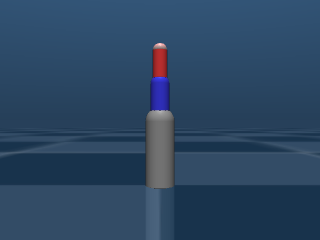

In [10]:
#longitudes de mi dedo
l0=0.044 #Longitud del segmento 1 en metros
l1=0.026 #longitud en metros
l2=0.023 #longitud en metros
#grosor
w0=0.01
w1=0.0065
w2=0.005
#damping
b=0.001
parameters={
    "l0":l0,
    "l1":l1,
    "l2":l2,
    "w0":w0,
    "w1":w1,
    "w2":w2,
    "b":b,
    "i1":l1/2,
    "i2":l2/2
}
xml_model=xml_model.format(**parameters)

#Se inicializa el modelo de simulación en mujoco
model = mujoco.MjModel.from_xml_string(xml_model)
renderer = mujoco.Renderer(model)
data = mujoco.MjData(model)
mujoco.mj_forward(model, data)
renderer.update_scene(data,camera="vista_plana")
media.show_image(renderer.render())
renderer.close()

# Definición de trayectoria de prueba

In [11]:
archivo_txt = 'Finger_coordinates.txt' 

# 2. Cargar los datos
# Tracker usa comas para separar, así que mantendremos sep=',' 
# Saltamos las 3 líneas de encabezado de metadatos (#multi:, mass, t,x,y)
nombres_columnas = ['t', 'x_A', 'y_A', 'x_B', 'y_B', 'x_C', 'y_C']
df = pd.read_csv(archivo_txt, skiprows=3, header=None, names=nombres_columnas, sep=',')

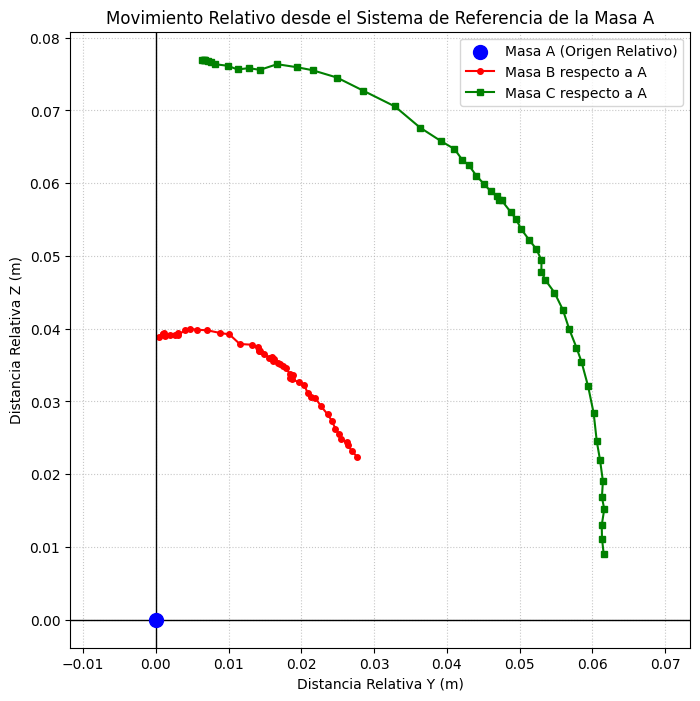

In [12]:
#Se calculan las posiciones relativas al punto A debido a que solo queremos theta 1 y theta 2
fixing_scale=1.9
df['y_B_rel'] = (df['x_B'] - df['x_A'])*fixing_scale
df['z_B_rel'] = (df['y_B'] - df['y_A'])*fixing_scale

df['y_C_rel'] = (df['x_C'] - df['x_A'])*fixing_scale
df['z_C_rel'] = (df['y_C'] - df['y_A'])*fixing_scale

plt.figure(figsize=(8, 8))
plt.scatter(0, 0, color='blue', s=100, label='Masa A (Origen Relativo)', zorder=5)
plt.plot(df['y_B_rel'], df['z_B_rel'], 'r-o', label='Masa B respecto a A', markersize=4)
plt.plot(df['y_C_rel'], df['z_C_rel'], 'g-s', label='Masa C respecto a A', markersize=4)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Distancia Relativa Y (m)')
plt.ylabel('Distancia Relativa Z (m)')
plt.title('Movimiento Relativo desde el Sistema de Referencia de la Masa A')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.axis('equal') # Importante para ver proporciones reales

plt.show()

#Se establecen los ángulo necesarios para theta 1 y theta 2 por medio de relaciones trigonométricas
df["theta1"]=np.arctan(df["y_B_rel"]/df["z_B_rel"])
df["theta2"]=(np.arctan(df["y_C_rel"]/df["z_C_rel"]))-df["theta1"]

# Funciones de utilidad

In [13]:
def build(df, timestep):
 
    t_orig = df["t"].values
    th1_orig = df["theta1"].values
    th2_orig = df["theta2"].values
    t_max = t_orig.max()
    t_new = np.arange(0, t_max, timestep)
 
    # Interpolar SOLO para tener más puntos
    cs1 = sp_interp.CubicSpline(t_orig, th1_orig)
    cs2 = sp_interp.CubicSpline(t_orig, th2_orig)
 
    th1 = cs1(t_new)
    th2 = cs2(t_new)
 
    # Suavizado FUERTE
    window = 121  # numero mas grande
    poly = 3
 
    th1_s = savgol_filter(th1, window, poly)
    th2_s = savgol_filter(th2, window, poly)
 
    # Derivadas desde señal suavizada
    vel1 = savgol_filter(th1_s, window, poly, deriv=1, delta=timestep)
    vel2 = savgol_filter(th2_s, window, poly, deriv=1, delta=timestep)
 
    acel1 = savgol_filter(th1_s, window, poly, deriv=2, delta=timestep)
    acel2 = savgol_filter(th2_s, window, poly, deriv=2, delta=timestep)
 
    return (
        np.vstack((th1_s, th2_s)).T,
        np.vstack((vel1, vel2)).T,
        np.vstack((acel1, acel2)).T,
        t_new
    )

#Acá se define la función de dinámica inversa, que toma el modelo de Mujoco, las posiciones, velocidades y aceleraciones deseadas, 
#y devuelve los torques necesarios para lograr esa trayectoria.
def inverse_dynamics(model,pos,vel,acel):
    """
    computes inverse dynamics
    """
    data = mujoco.MjData(model)
    tau = np.zeros((len(pos), model.nu))
    for i in range(len(pos)):
        data.qpos[:] = pos[i] # Pos
        data.qvel[:] = vel[i] # Vel
        data.qacc[:] = acel[i] # Accel
        mujoco.mj_inverse(model, data)
        tau[i, :] = data.qfrc_inverse.copy()
    return tau

#Aca se define la función de simulación, que toma el modelo de Mujoco, las posiciones, velocidades y torques deseados, el vector de tiempo y el framerate para la simulación y video.
def run_torque_simulation(model, q_des, qd_des,tau_des, t_uniform,fps):
    """
    Simulation to verify if calculated torques are following desired trayectory

    Arg:
        model: mujoco model that was used to calculate inverse dynamics
        q_des: stack of position data for each joint
        qd_des: stack of velocity data for each joint
        tau_des: torque values obtained in inverse dynamcis
        t_uniform: uniform time vector of data
        fps: framerate for video and simulation
    
    Returns
        arrays of postion and velocity of the simulation

    """
    #Inicialization of model data and render
    data = mujoco.MjData(model)
    renderer = mujoco.Renderer(model)

    #Frame skip calulation for smoother video
    frame_skip = max(1, int(len(t_uniform) / (fps * (t_uniform[-1] - t_uniform[0]))))

    #Variable inicialization
    q_hist, qd_hist = [], []
    frames = []
    pos_c = []
    acc_1 = []
    acc_2 = []
    true_states = []

    #Inicial values and step simulation 
    n_steps = len(q_des)
    data.qpos[:] = q_des[0]
    data.qvel[:] = qd_des[0]

    for i in range(n_steps):
        data.ctrl[:] = tau_des[i]
        mujoco.mj_step(model, data)
        pos_c.append(data.sensor('pos_c').data.copy())
        acc_1.append(data.sensor("acc_i1").data.copy())
        acc_2.append(data.sensor('acc_i2').data.copy())
    
        #añadimos valores al vector de estado
        theta1_true=data.qpos[0]
        omega1_true=data.qvel[0]

        theta2_true=data.qpos[1]
        omega2_true=data.qvel[1]
        true_states.append(np.array([[theta1_true],[omega1_true],[theta2_true],[omega2_true]]))

        

        #Saving of simulation data
        q_hist.append(data.qpos.copy())
        qd_hist.append(data.qvel.copy())

        #Frame save 
        if i % frame_skip == 0:
            renderer.update_scene(data,camera="vista_plana")
            frames.append(renderer.render())


    renderer.close()
    return np.array(q_hist), np.array(qd_hist), frames,pos_c,acc_1,acc_2,true_states

#cinemática directa para la posición del punto C
def forward_kinematics(theta1,theta2):
    """
    Computes point C position from joint angles

    theta1: theta1 angle value (radians)
    theta2: theta2 angle value (radians)
    returns: (y,z) point C, position as x coordinate is always 0
    """
    #computes point B coordinates
    yB=l1*np.sin(theta1)
    zB=l0+l1*np.cos(theta1)
    #computes point C coordinates
    y=-(yB+l2*np.sin(theta1+theta2))
    z=(zB+l2*np.cos(theta1+theta2))
    return y,z

timestep=model.opt.timestep
#build(df["theta1"],df["theta2"],df["t"],n_steps)

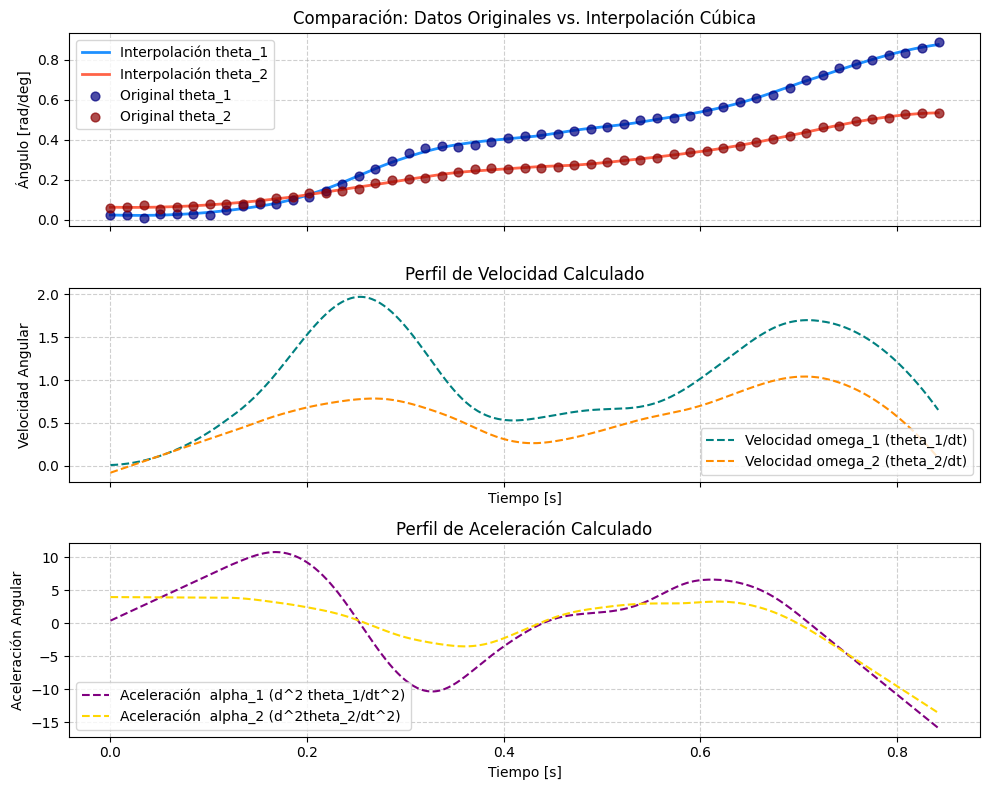

In [14]:
pos, vel, acel, t_array = build(df, timestep)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# --- PANEL 1: POSICIONES (Interpolación vs Original) ---
ax1.plot(t_array, pos[:, 0], color='dodgerblue', label='Interpolación theta_1', linewidth=2)
ax1.plot(t_array, pos[:, 1], color='tomato', label='Interpolación theta_2', linewidth=2)

# Graficamos los datos originales (puntos)
ax1.scatter(df["t"], df["theta1"], color='navy', s=40, label='Original theta_1', alpha=0.7, zorder=5)
ax1.scatter(df["t"], df["theta2"], color='darkred', s=40, label='Original theta_2', alpha=0.7, zorder=5)

ax1.set_title('Comparación: Datos Originales vs. Interpolación Cúbica', fontsize=12)
ax1.set_ylabel('Ángulo [rad/deg]')
ax1.legend(loc='best')
ax1.grid(True, linestyle='--', alpha=0.6)

# --- PANEL 2: VELOCIDADES (Derivadas) ---
# Aquí solo graficamos las líneas porque no tienes "velocidad original" en el DF
ax2.plot(t_array, vel[:, 0], color='teal', label='Velocidad omega_1 (theta_1/dt)', linestyle='--')
ax2.plot(t_array, vel[:, 1], color='darkorange', label='Velocidad omega_2 (theta_2/dt)', linestyle='--')

ax2.set_title('Perfil de Velocidad Calculado', fontsize=12)
ax2.set_xlabel('Tiempo [s]')
ax2.set_ylabel('Velocidad Angular')
ax2.legend(loc='best')
ax2.grid(True, linestyle='--', alpha=0.6)

# --- PANEL 3: ACELERACIONES (Segundas Derivadas) ---
# Aquí solo graficamos las líneas porque no tienes "aceleración original" en el DF
ax3.plot(t_array, acel[:, 0], color='purple', label='Aceleración  alpha_1 (d^2 theta_1/dt^2)', linestyle='--')
ax3.plot(t_array, acel[:, 1], color='gold', label='Aceleración  alpha_2 (d^2theta_2/dt^2)', linestyle='--')

ax3.set_title('Perfil de Aceleración Calculado', fontsize=12)
ax3.set_xlabel('Tiempo [s]')
ax3.set_ylabel('Aceleración Angular')
ax3.legend(loc='best')
ax3.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Visualización de la dinámica inversa

In [15]:
torque_values = inverse_dynamics(model,pos,vel,acel)
fps = 60
#acá se muestra la tayectoria simulada con los torques calculados en la dinámica inversa, y se guardan los frames para luego mostrar el video.
q_hist, qd_hist, frames ,pos_c,acc_1,acc_2,true_states= run_torque_simulation(model,pos,vel,torque_values,t_array,fps=60)

#Defino las variables que corresponden a las lecturas de los sensores y la posición del punto C.
pos_c = np.array(pos_c)
sensor1 = np.array(acc_1)
sensor2 = np.array(acc_2)

media.show_video(frames, fps=fps)  

# Lectura de Sensores y Ruido

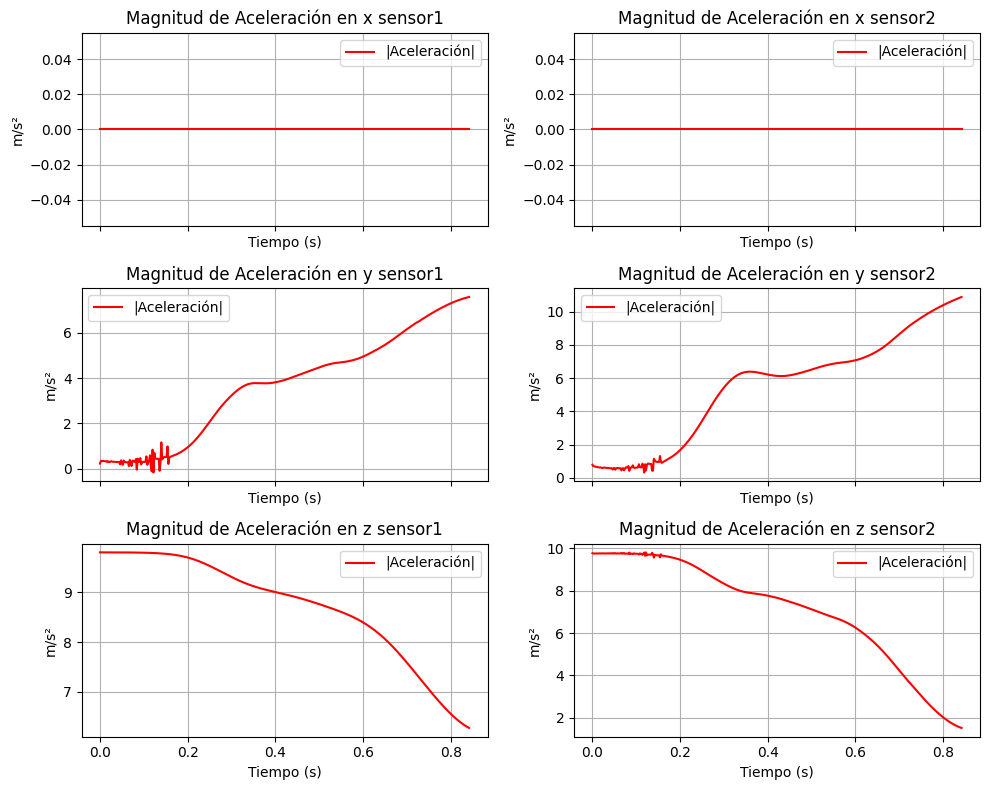

In [16]:
# Acá se grafican las lecturas de los sensores en cada eje.
fig, ax = plt.subplots(3, 2, figsize=(10, 8), sharex=True)
#Gráficas: sensor 1
ax[0,0].plot(t_array, sensor1[:,0], 'r-', label='|Aceleración|')
ax[0,0].set_title("Magnitud de Aceleración en x sensor1")
ax[0,0].set_xlabel("Tiempo (s)")
ax[0,0].set_ylabel("m/s²")
ax[0,0].grid(True)
ax[0,0].legend()


ax[1,0].plot(t_array, sensor1[:,1], 'r-', label='|Aceleración|')
ax[1,0].set_title("Magnitud de Aceleración en y sensor1")
ax[1,0].set_xlabel("Tiempo (s)")
ax[1,0].set_ylabel("m/s²")
ax[1,0].grid(True)
ax[1,0].legend()

ax[2,0].plot(t_array, sensor1[:,2], 'r-', label='|Aceleración|')
ax[2,0].set_title("Magnitud de Aceleración en z sensor1")
ax[2,0].set_xlabel("Tiempo (s)")
ax[2,0].set_ylabel("m/s²")
ax[2,0].grid(True)
ax[2,0].legend()

#Gráficas: sensor 2
ax[0,1].plot(t_array, sensor2[:,0], 'r-', label='|Aceleración|')
ax[0,1].set_title("Magnitud de Aceleración en x sensor2")
ax[0,1].set_xlabel("Tiempo (s)")
ax[0,1].set_ylabel("m/s²")
ax[0,1].grid(True)
ax[0,1].legend()


ax[1,1].plot(t_array, sensor2[:,1], 'r-', label='|Aceleración|')
ax[1,1].set_title("Magnitud de Aceleración en y sensor2")
ax[1,1].set_xlabel("Tiempo (s)")
ax[1,1].set_ylabel("m/s²")
ax[1,1].grid(True)
ax[1,1].legend()

ax[2,1].plot(t_array, sensor2[:,2], 'r-', label='|Aceleración|')
ax[2,1].set_title("Magnitud de Aceleración en z sensor2")
ax[2,1].set_xlabel("Tiempo (s)")
ax[2,1].set_ylabel("m/s²")
ax[2,1].grid(True)
ax[2,1].legend()

plt.tight_layout()
plt.show()

# Mostrar video
media.show_video(frames, fps=fps)    

Text(0.5, 1.0, 'Trayectoria del punto C')

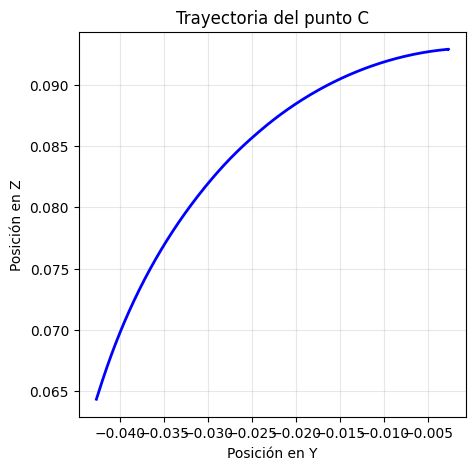

In [17]:
# Se muestra la trayectoria realizada por el punto C en el espacio Y-Z, que es el plano de movimiento del dedo.
plt.figure(figsize=(5,5))
plt.plot(pos_c[:,1],pos_c[:,2],"b-",linewidth=2, label='Posición del punto P')
plt.grid(True, alpha=0.3)
plt.xlabel("Posición en Y")
plt.ylabel("Posición en Z")
plt.title("Trayectoria del punto C")

# PROCESAMIENTO DE DATOS PARA SIMULACIÓN DE RUIDO

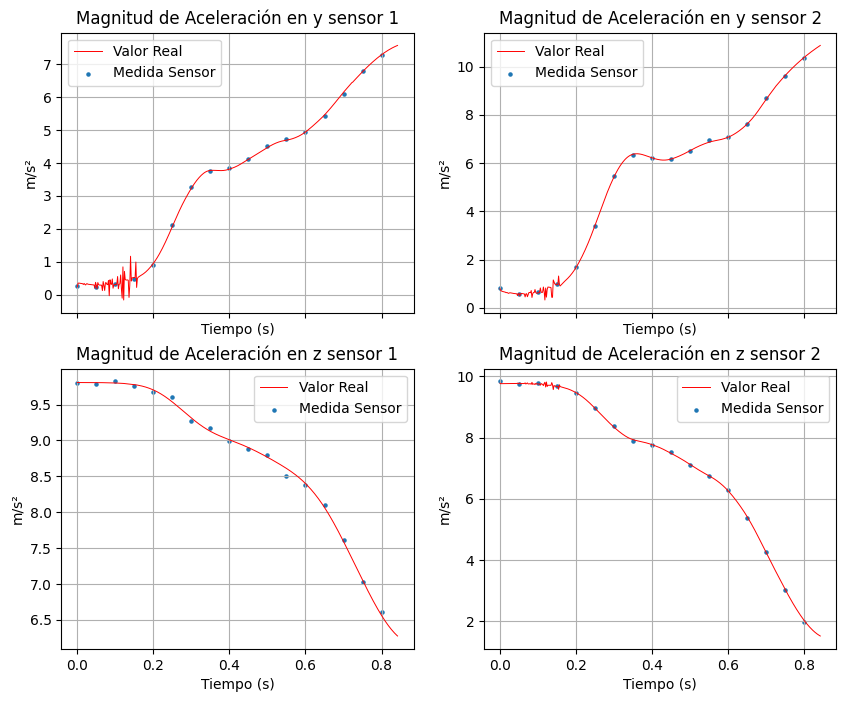

In [18]:
#Creamos los valores de las medidas con ruido
g=9.81 #gravedad (m/s)
bus_type=10#bit
acc_sensor_range=2*g
acc_noise_std=(2*acc_sensor_range)/(2**bus_type)
np.random.seed(42)
measurements_acc1 = []
measurements_acc2 = []
for i in range(len(pos_c)):
    x=0
    acc1_y=sensor1[i,1]+np.random.randn()*acc_noise_std
    acc1_z=sensor1[i,2]+np.random.randn()*acc_noise_std
    acc2_y=sensor2[i,1]+np.random.randn()*acc_noise_std
    acc2_z=sensor2[i,2]+np.random.randn()*acc_noise_std
    sensor1_meas=np.array([[x],[acc1_y],[acc1_z]])
    sensor2_meas=np.array([[x],[acc2_y],[acc2_z]])
    measurements_acc1.append(sensor1_meas)
    measurements_acc2.append(sensor2_meas)

#visualizamos las mediciones con respecto a los valores reales
measurements_acc1_y=[measurements_acc1[s][1] for s in range(len(measurements_acc1))]
measurements_acc1_z=[measurements_acc1[s][2] for s in range(len(measurements_acc1))]
measurements_acc2_y=[measurements_acc2[s][1] for s in range(len(measurements_acc2))]
measurements_acc2_z=[measurements_acc2[s][2] for s in range(len(measurements_acc2))]

fig, ax = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
ax[0,0].plot(t_array, sensor1[:,1], 'r-', label='Valor Real',lw=0.7)
ax[0,0].scatter(t_array[::25],np.array(measurements_acc1_y)[::25].flatten(),label="Medida Sensor",s=5)
ax[0,0].set_title("Magnitud de Aceleración en y sensor 1")
ax[0,0].set_xlabel("Tiempo (s)")
ax[0,0].set_ylabel("m/s²")
ax[0,0].grid(True)
ax[0,0].legend()

ax[1,0].plot(t_array, sensor1[:,2], 'r-', label='Valor Real',lw=0.7)
ax[1,0].scatter(t_array[::25],np.array(measurements_acc1_z)[::25].flatten(),label="Medida Sensor",s=5)
ax[1,0].set_title("Magnitud de Aceleración en z sensor 1")
ax[1,0].set_xlabel("Tiempo (s)")
ax[1,0].set_ylabel("m/s²")
ax[1,0].grid(True)
ax[1,0].legend()

ax[0,1].plot(t_array, sensor2[:,1], 'r-', label='Valor Real',lw=0.7)
ax[0,1].scatter(t_array[::25],np.array(measurements_acc2_y)[::25].flatten(),label="Medida Sensor",s=5)
ax[0,1].set_title("Magnitud de Aceleración en y sensor 2")
ax[0,1].set_xlabel("Tiempo (s)")
ax[0,1].set_ylabel("m/s²")
ax[0,1].grid(True)
ax[0,1].legend()

ax[1,1].plot(t_array, sensor2[:,2], 'r-', label='Valor Real',lw=0.7)
ax[1,1].scatter(t_array[::25],np.array(measurements_acc2_z)[::25].flatten(),label="Medida Sensor",s=5)
ax[1,1].set_title("Magnitud de Aceleración en z sensor 2")
ax[1,1].set_xlabel("Tiempo (s)")
ax[1,1].set_ylabel("m/s²")
ax[1,1].grid(True)
ax[1,1].legend()

# Planteamiento del sistema

In [19]:

#Defino los IDs para los cuerpos que me interesan
seg1_id=mujoco.mj_name2id(model,mujoco.mjtObj.mjOBJ_BODY,"seg1")
seg2_id=mujoco.mj_name2id(model,mujoco.mjtObj.mjOBJ_BODY,"seg2")
#calculo masa e inercia para el cuerpo 1

mass_seg1=model.body_mass[seg1_id]
inertia_seg1=model.body_inertia[seg1_id]
#calculo masa e inercia para el cuerpo 2

mass_seg2=model.body_mass[seg2_id]
inertia_seg2=model.body_inertia[seg2_id]

print("Las propiedades de cada cuerpo son las siguientes")
print("Segmento 1")
print(f"Longitud: {l1*100} cm, masa: {mass_seg1*1000} gr, inercia: {inertia_seg1[0]} kg/m^2")
print("-"*109)
print("Segmento 2")
print(f"Longitud: {l2*100} cm, masa: {mass_seg2*1000} gr, inercia: {inertia_seg2[0]} kg/m^2")



Las propiedades de cada cuerpo son las siguientes
Segmento 1
Longitud: 2.6 cm, masa: 4.60138603995785 gr, inercia: 5.176127915011335e-07 kg/m^2
-------------------------------------------------------------------------------------------------------------
Segmento 2
Longitud: 2.3 cm, masa: 2.33001455141243 gr, inercia: 1.8798505040917924e-07 kg/m^2


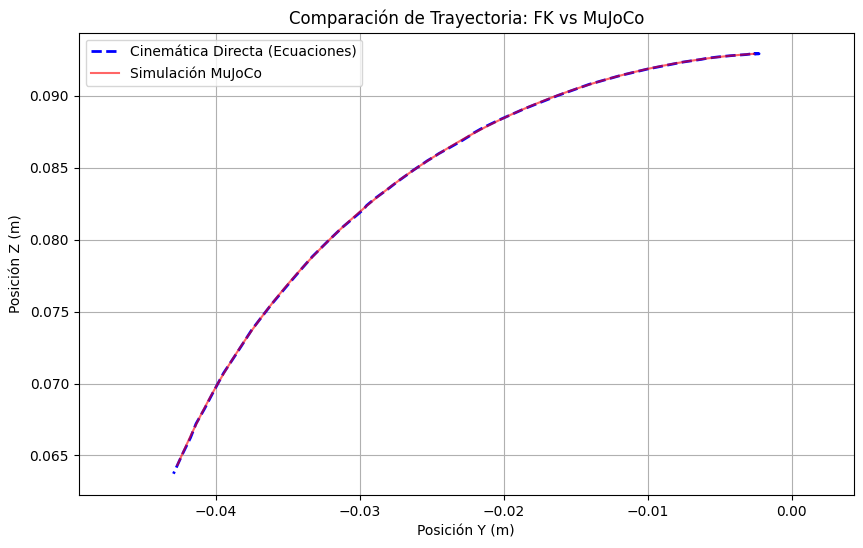

In [20]:
#comprobamos la cinemática directa
# 1. Preparar los datos de la Cinemática Directa (FK)
y_fk = []
z_fk = []

# Asumiendo que l1, l2, l3 ya están definidos en tu script
for angle1,angle2 in zip(df["theta1"],df["theta2"]):
    
    y_val, z_val = forward_kinematics(angle1, angle2)
    y_fk.append(y_val)
    z_fk.append(z_val)

# 2. Preparar los datos de MuJoCo (pos_c)
# Convertimos la lista de arrays (1,3) en un array de numpy de (N, 3)
pos_c_array = np.array(pos_c).reshape(-1, 3)
y_mujoco = pos_c_array[:, 1] # Columna 1 es Y
z_mujoco = pos_c_array[:, 2] # Columna 2 es Z

# 3. Crear el Plot
plt.figure(figsize=(10, 6))

# Trazado de la cinemática directa (teórica)
plt.plot(y_fk, z_fk, label='Cinemática Directa (Ecuaciones)', linestyle='--', color='blue', linewidth=2)

# Trazado de los datos de MuJoCo (simulación)
plt.plot(y_mujoco, z_mujoco, label='Simulación MuJoCo', color='red', alpha=0.6)

# Configuración de la gráfica
plt.title('Comparación de Trayectoria: FK vs MuJoCo')
plt.xlabel('Posición Y (m)')
plt.ylabel('Posición Z (m)')
plt.legend()
plt.grid(True)
plt.axis('equal') # Importante para ver la geometría real sin deformación
plt.show()

# IMPLEMENTACION DE FILTRO DE EKF (EN PROCESO - CODIGO NO TERMINADO)

In [21]:
# Se definia la función de transicion de estado para el sistema.
def arm_f(x,dt):
    """
    State transition function x_{k+1}=f{x_k,dt}

    x: (4,1) state vector [theta1, thetadot1, theta2, thetadot2].T
    dt: time step (seconds)
    Returns (4,1) Predicted state
    """
    theta1_val = x[0, 0]
    omega1_val = x[1, 0]
    theta2_val = x[2, 0]
    omega2_val = x[3, 0]

    aceleraciones = calc_alpha(theta1_val, theta2_val, omega1_val, omega2_val)
    alpha1 = float(aceleraciones[0, 0])
    alpha2 = float(aceleraciones[1, 0])
    
    theta1_new = theta1_val + dt * omega1_val
    omega1_new = omega1_val + dt * alpha1
    theta2_new = theta2_val + dt * omega2_val
    omega2_new = omega2_val + dt * alpha2

    return np.array([[theta1_new], [omega1_new], [theta2_new], [omega2_new]])  

In [22]:
t_test=0.004
theta1_test=np.deg2rad(30 * np.sin(t_test))
theta2_test=np.deg2rad((40 * np.cos(t_test))-40)
y_test=pos_c[int(t_test/timestep)-1][1]
z_test=pos_c[int(t_test/timestep)-1][2]
y_ee,z_ee=forward_kinematics(theta1_test,theta2_test)

error=np.sqrt((y_ee-y_test)**2 + (z_ee-z_test)**2)
#ACÁ HAY UN CONLICTO DE VARIABLES, como se puede ver forward_kinematics está soltando valores con simbolos, esto se debe a que las variables L_1, L_2 y L_3 fueron 
#reasignadas cuando se puso la parte de Definición del sistema, dejaré esta parte del codigo comentada por el momento
# print(f'Position error: {error:.6e} m')
# assert error < 1e-4, f'Forward kinematics error too large: {error}'
# print('Forward kinematics VERIFIED (error < 1e-4 m)')
print("El error es menor a 1e-4:", error < 1e-4)

El error es menor a 1e-4: False


In [23]:
# Quick sanity check
dt=model.opt.timestep
x_test = np.array([[0.3], [0.5], [-0.5], [-0.3]])
x_next = arm_f(x_test, dt)
print(f'Test state:     {x_test.T}')
print(f'Predicted next: {x_next.T}')

Test state:     [[ 0.3  0.5 -0.5 -0.3]]
Predicted next: [[ 0.301       0.89048932 -0.5006     -1.38199562]]


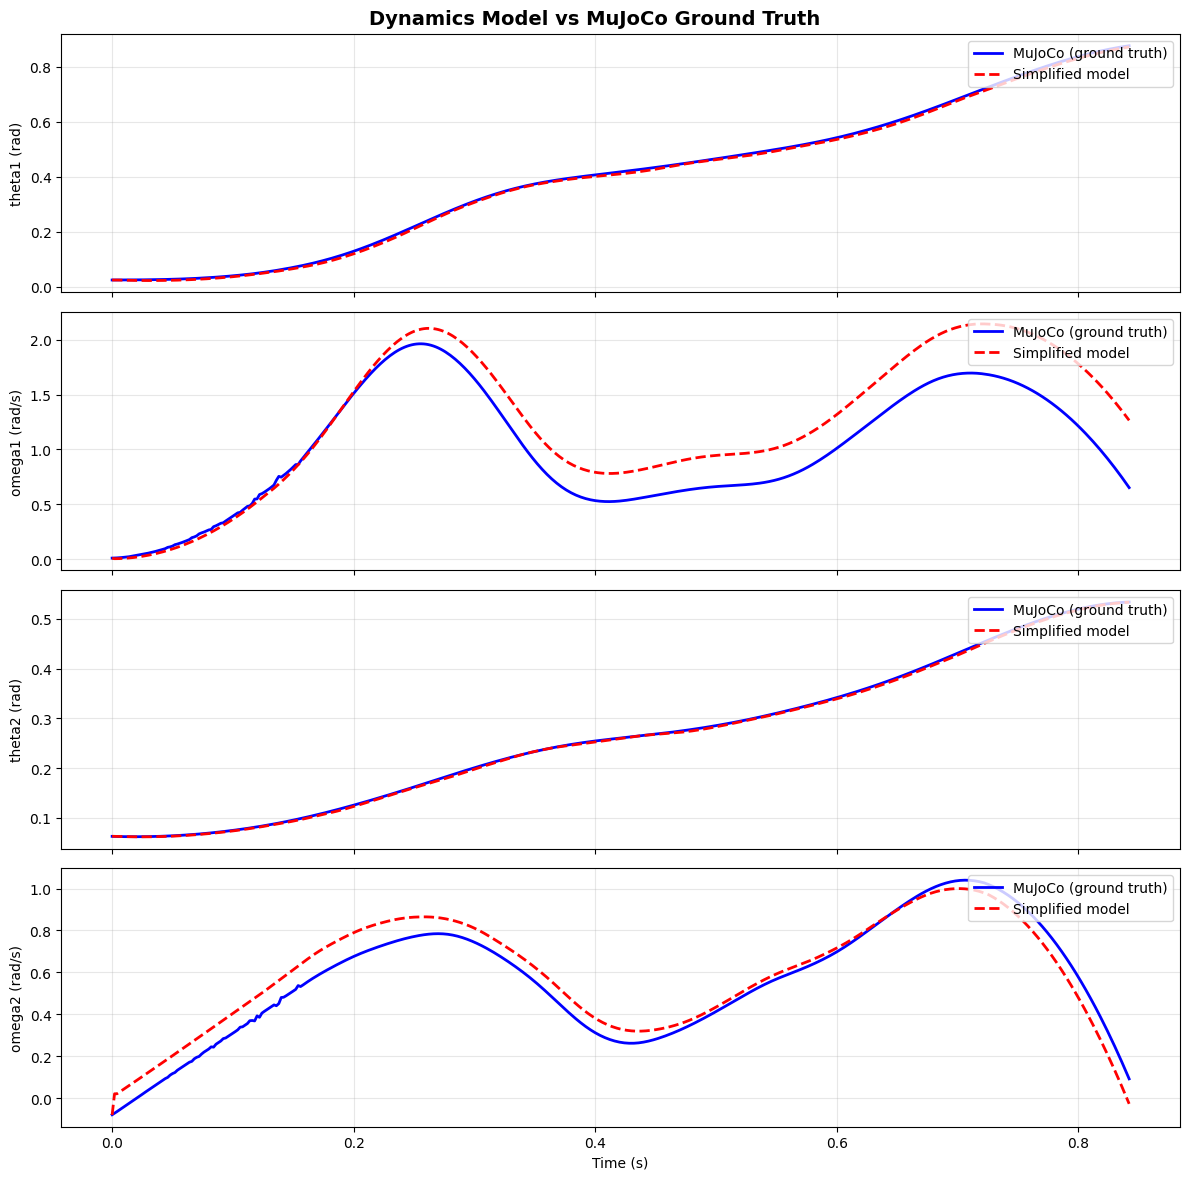

In [24]:
# Compare dynamics model against MuJoCo ground
x_model=np.array([[pos[0][0]], [vel[0][0]], [pos[0][1]], [vel[0][1]]])
model_states = [x_model.copy()]

for k in range(len(true_states) - 1):
    x_model = arm_f(x_model, dt)
    model_states.append(x_model.copy())
    x_model=np.array([[pos[k][0]], [vel[k][0]], [pos[k][1]], [vel[k][1]]])

# Plot comparison: 4 subplots showing all states
labels = ['theta1 (rad)', 'omega1 (rad/s)',
          'theta2 (rad)', 'omega2 (rad/s)']

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

for i in range(4):
    true_vals = [s[i, 0] for s in true_states]
    model_vals = [s[i, 0] for s in model_states]

    axes[i].plot(t_array, true_vals, 'b-', lw=2, label='MuJoCo (ground truth)')
    axes[i].plot(t_array, model_vals, 'r--', lw=2, label='Simplified model')
    axes[i].set_ylabel(labels[i])
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Dynamics Model vs MuJoCo Ground Truth', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
def arm_F_numerical(x, dt, eps=1e-7):
    """
    Compute the 4x4 Jacobian numerically using finite differences.
    
    x: (4,1) state vector
    dt: time step
    eps: perturbation size for finite differences
    Returns: (4,4) Jacobian matrix F = df/dx
    """
    n = x.shape[0]
    F = np.zeros((n, n))
    x_flat = x.flatten()
    for i in range(n):
        def f_i(x_flat_in, idx=i):
            x_col = x_flat_in.reshape(-1, 1)
            return arm_f(x_col, dt)[idx, 0]
        F[i, :] = approx_fprime(x_flat, f_i, eps)
    return F

# Verify Jacobian at multiple test states
test_states_jac = [
    ('All zeros',                    np.array([[0.0], [0.0], [0.0],  [0.0]])),
    ('Small angles',                 np.array([[0.3], [0.0], [-0.5], [0.0]])),
    ('With velocities',              np.array([[0.3], [0.5], [-0.5], [-0.3]])),
    ('Large angles',                 np.array([[1.5], [1.0], [1.0],  [-0.5]])),
]

print('Jacobian Verification (numerical eps=1e-7 vs eps=1e-5)')
print('=' * 70)
all_passed = True
for name, x_test in test_states_jac:
    F1 = arm_F_numerical(x_test, dt, eps=1e-7)
    F2 = arm_F_numerical(x_test, dt, eps=1e-5)
    error = np.max(np.abs(F1 - F2))
    status = 'PASS' if error < 1e-4 else 'FAIL'
    if error >= 1e-4:
        all_passed = False
    print(f'\n{name}:')
    print(f'  Max difference: {error:.2e} [{status}]')

print('\n' + '=' * 70)
assert all_passed, 'Jacobian verification FAILED at one or more test points!'
print('All Jacobian tests PASSED (difference < 1e-4)')

Jacobian Verification (numerical eps=1e-7 vs eps=1e-5)

All zeros:
  Max difference: 1.56e-10 [PASS]

Small angles:
  Max difference: 1.23e-05 [PASS]

With velocities:
  Max difference: 1.23e-05 [PASS]

Large angles:
  Max difference: 4.05e-06 [PASS]

All Jacobian tests PASSED (difference < 1e-4)


In [26]:
# Examine the Jacobian structure at equilibrium
x_eq = np.array([[0.0], [0.0], [0.0], [0.0]])
F_eq = arm_F_numerical(x_eq, dt)

print('Jacobian at equilibrium (all states zero):')
print()
np.set_printoptions(precision=6, suppress=True)
print(F_eq)

Jacobian at equilibrium (all states zero):

[[ 1.        0.002     0.        0.      ]
 [ 0.858313  1.       -0.390287  0.      ]
 [ 0.        0.        1.        0.002   ]
 [-1.003953  0.        1.998253  1.      ]]


# Measurement models

In [27]:
# ============ Modelos de me medición ============

def h_acel(x):
    """
    Medida de los acelerómetros
    """
    theta1_val = x[0, 0]
    omega1_val = x[1, 0]
    theta2_val = x[2, 0]
    omega2_val = x[3, 0]

    aceleraciones = calc_alpha(theta1_val, theta2_val, omega1_val, omega2_val)
    alpha1 = float(aceleraciones[0, 0])
    alpha2 = float(aceleraciones[1, 0])
    
    h_vals = h_fun(theta1_val, omega1_val, alpha1, theta2_val, omega2_val, alpha2)

    return h_vals

def H_acel(x, eps=1e-7):
    """
    Compute the Jacobian of the measurement function numerically using finite differences.
    
    x: (4,1) state vector [theta1, omega1, theta2, omega2].T
    eps: perturbation size for finite differences
    Returns: (4,4) Measurement Jacobian matrix H = dh/dx
    """
    n = x.shape[0]  # Dimensión del vector de estado (4)
    m = 4           # Dimensión del vector de medición (4 aceleraciones lineales)
    
    H = np.zeros((m, n))
    x_flat = x.flatten()
    
    for i in range(m):
        def h_i(x_flat_in, idx=i):
            # Reconstruimos el vector columna
            x_col = x_flat_in.reshape(-1, 1)
            # Evaluamos la medida esperada con la función de medición no lineal
            return h_acel(x_col)[idx, 0]
            
        # approx_fprime calcula el gradiente numérico de h_i respecto a los 4 estados
        H[i, :] = approx_fprime(x_flat, h_i, eps)
        
    return H

In [28]:
# Se predice el estado y la covarianza utilizando el modelo dinámico del brazo.
# Propaga la estimación del estado en el tiempo antes de usar las mediciones.

def ekf_predict(x_hat, P, dt, Q):
    """
    EKF prediction step
    """
    # Estado predicho
    x_minus = arm_f(x_hat, dt)

    # Jacobiano del modelo dinámico (numérico)
    eps = 1e-6 # pequeño para aproximar la derivada numéricamente
    F = arm_F_numerical(x_hat, dt, eps=eps)

    # Covarianza predicha
    P_minus = F @ P @ F.T + Q

    return x_minus, P_minus

def ekf_update(x, P, z, h, H, R):
    """
    EKF Update Step: correct prediction with a measurement.
    
    x: (n,1) predicted state
    P: (n,n) predicted covariance
    z: (m,1) measurement
    h: measurement function h(x) -> (m,1)
    H: Jacobian function H(x) -> (m,n)
    R: (m,m) measurement noise covariance (how much we distrust the sensor)
    
    Returns: (x_upd, P_upd)
    """
    # Linearize measurement model at predicted state
    H_k = H(x)                             # (m,n) measurement Jacobian
    
    # Innovation: difference between actual measurement and predicted measurement
    y = z - h(x)                           # (m,1) innovation ("surprise")
    
    # Innovation covariance: how uncertain is our predicted measurement?
    S = H_k @ P @ H_k.T + R                # (m,m)
    
    # Kalman gain: how much to trust measurement vs prediction
    # Large K -> trust measurement more; Small K -> trust prediction more
    K = P @ H_k.T @ np.linalg.inv(S)       # (n,m)
    
    # Correct state estimate with weighted innovation
    x_upd = x + K @ y                      # (n,1)
    
    # Update covariance using Joseph form for numerical stability
    # (Standard form P = (I-KH)P can lose positive-definiteness)
    I_KH = np.eye(x.shape[0]) - K @ H_k    # (n,n)
    P_upd = I_KH @ P @ I_KH.T + K @ R @ K.T  # (n,n) Joseph form
    
    return x_upd, P_upd

In [29]:
# Se ejecutan iterativamente los pasos de predicción y actualización para cada instante de tiempo.
# Obtiene la estimación del estado del sistema a lo largo de toda la trayectoria.

dt = t_array[1] - t_array[0]

# Inicialización
x_hat = np.array([[true_states[0][0,0]],
                  [true_states[0][1,0]],
                  [true_states[0][2,0]],
                  [true_states[0][3,0]]])

P = np.eye(4) * 0.01
Q = np.eye(4) * 1e-4
R = np.eye(4) * (acc_noise_std**2)

# Inicialización de historiales con el estado en t=0
x_hist = [x_hat.copy()]
P_hist = [P.copy()]

# Empezamos el bucle en k=1 para sincronizar la predicción con la medida
for k in range(1, len(t_array)):

    # 1. PREDICCIÓN: Proyectamos el estado de k-1 hacia k
    x_minus, P_minus = ekf_predict(x_hat, P, dt, Q)

    # 2. MEDICIÓN: Extraemos la lectura de los sensores exactamente en el instante k
    z = np.array([
        [sensor1[k,1]], 
        [sensor1[k,2]], 
        [sensor2[k,1]],
        [sensor2[k,2]]
    ])

    # 3. ACTUALIZACIÓN: Corregimos la predicción k usando la medida k
    # Asegúrate de pasar la función H que arreglamos (H_acel_numerical)
    x_hat, P = ekf_update(x_minus, P_minus, z, h_acel, H_acel, R)

    # Guardamos el estado corregido
    x_hist.append(x_hat.copy())
    P_hist.append(P.copy())

In [30]:
# Se comparan las estimaciones del EKF con el estado real proveniente de la simulación.
# Permite evaluar la precisión y estabilidad del estimador.
# EKF
x_ekf = np.array(x_hist).squeeze()  # (N,4)

# Estado real
x_true = np.array([s.flatten() for s in true_states])  # (N,4)

# Separación por componentes
theta1_true, omega1_true = x_true[:,0], x_true[:,1]
theta2_true, omega2_true = x_true[:,2], x_true[:,3]

theta1_ekf,  omega1_ekf  = x_ekf[:,0],  x_ekf[:,1]
theta2_ekf,  omega2_ekf  = x_ekf[:,2],  x_ekf[:,3]

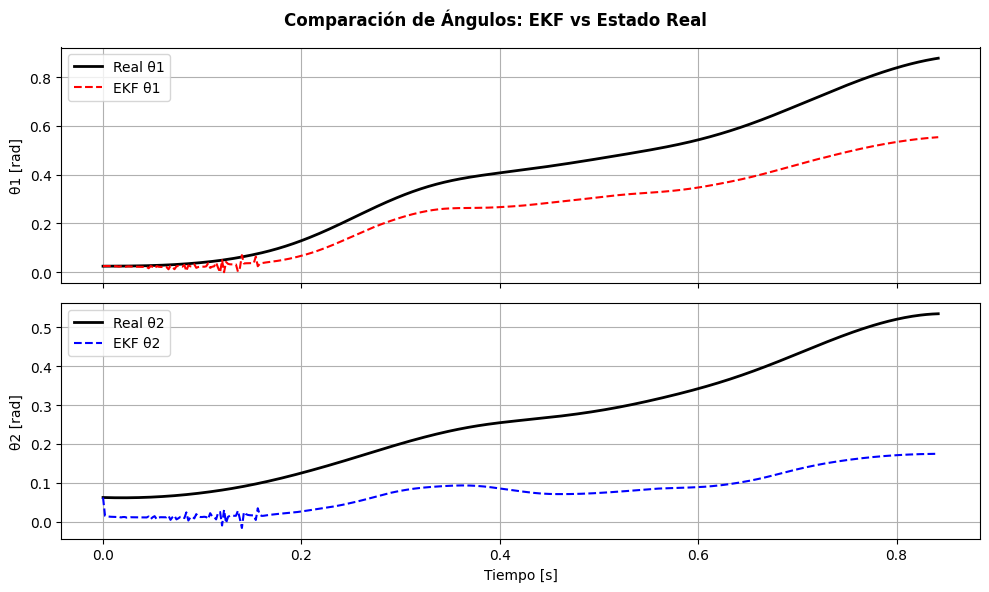

In [31]:
fig, axs = plt.subplots(2, 1, figsize=(10,6), sharex=True)

axs[0].plot(t_array, theta1_true, 'k-', lw=2, label="Real θ1")
axs[0].plot(t_array, theta1_ekf, 'r--', label="EKF θ1")
axs[0].set_ylabel("θ1 [rad]")
axs[0].legend(); axs[0].grid(True)

axs[1].plot(t_array, theta2_true, 'k-', lw=2, label="Real θ2")
axs[1].plot(t_array, theta2_ekf, 'b--', label="EKF θ2")
axs[1].set_ylabel("θ2 [rad]")
axs[1].set_xlabel("Tiempo [s]")
axs[1].legend(); axs[1].grid(True)

plt.suptitle("Comparación de Ángulos: EKF vs Estado Real", fontweight="bold")
plt.tight_layout(); plt.show()

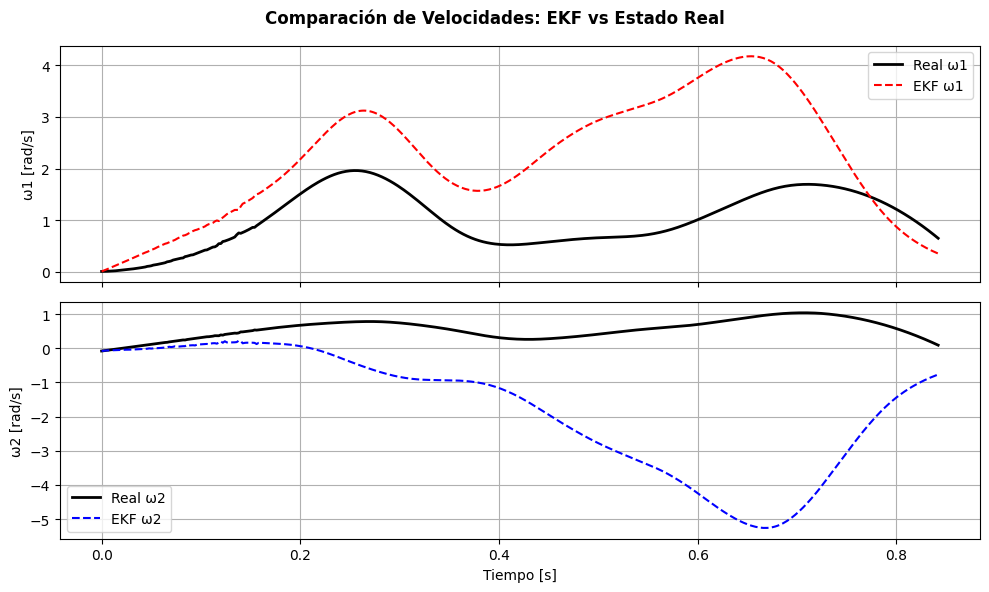

In [32]:
fig, axs = plt.subplots(2, 1, figsize=(10,6), sharex=True)

axs[0].plot(t_array, omega1_true, 'k-', lw=2, label="Real ω1")
axs[0].plot(t_array, omega1_ekf, 'r--', label="EKF ω1")
axs[0].set_ylabel("ω1 [rad/s]")
axs[0].legend(); axs[0].grid(True)

axs[1].plot(t_array, omega2_true, 'k-', lw=2, label="Real ω2")
axs[1].plot(t_array, omega2_ekf, 'b--', label="EKF ω2")
axs[1].set_ylabel("ω2 [rad/s]")
axs[1].set_xlabel("Tiempo [s]")
axs[1].legend(); axs[1].grid(True)

plt.suptitle("Comparación de Velocidades: EKF vs Estado Real", fontweight="bold")
plt.tight_layout(); plt.show()

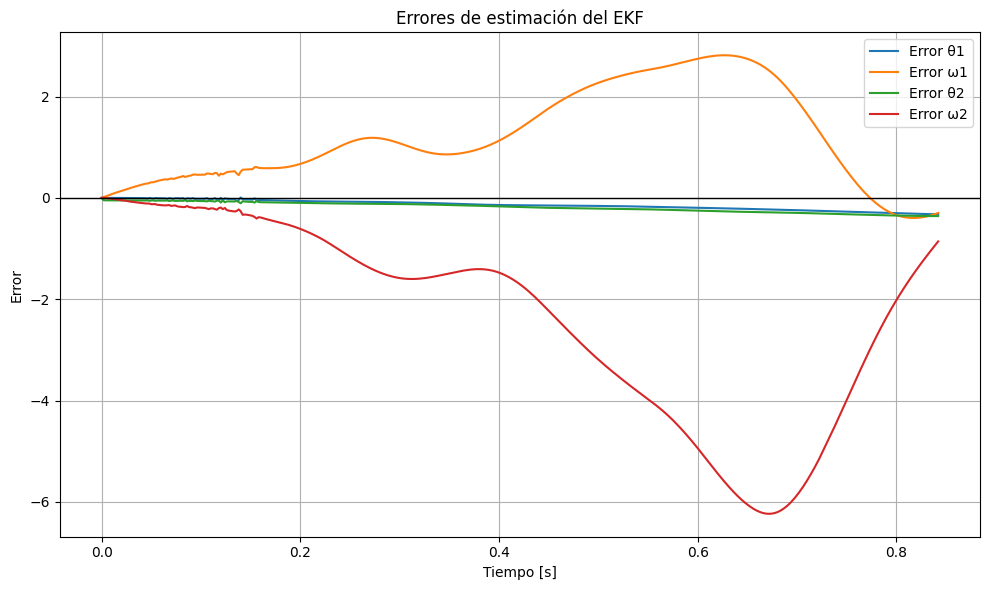

In [33]:
err = x_ekf - x_true

labels = ["θ1", "ω1", "θ2", "ω2"]

plt.figure(figsize=(10,6))
for i in range(4):
    plt.plot(t_array, err[:,i], label=f"Error {labels[i]}")

plt.axhline(0, color='k', lw=1)
plt.xlabel("Tiempo [s]")
plt.ylabel("Error")
plt.title("Errores de estimación del EKF")
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()


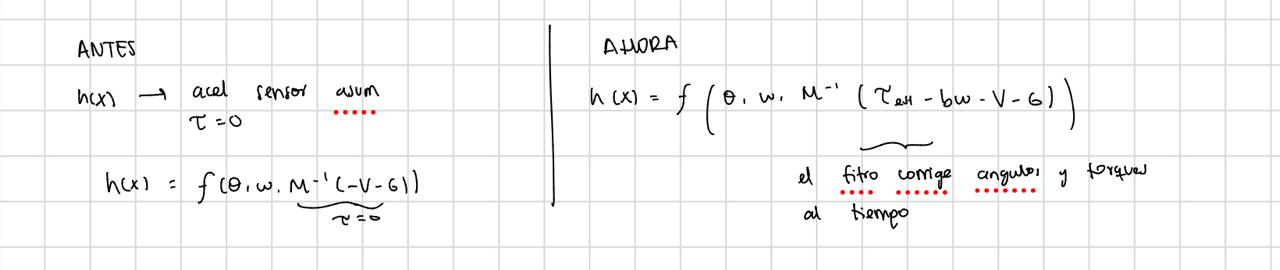

In [34]:
def arm_f_augmented(x, dt):
    theta1_val = x[0, 0]
    omega1_val = x[1, 0]
    theta2_val = x[2, 0]
    omega2_val = x[3, 0]
    tau1_val   = x[4, 0]
    tau2_val   = x[5, 0]

    tau_est = np.array([tau1_val, tau2_val])

    sd = {theta1: theta1_val, theta2: theta2_val,
          thetadot1: omega1_val, thetadot2: omega2_val}
    M_np = np.array([[float(M_num[i,j].subs(sd).evalf()) for j in range(2)]
                     for i in range(2)], dtype=np.float64)
    V_np = np.array([float(V_num[i].subs(sd).evalf()) for i in range(2)], dtype=np.float64)
    G_np = np.array([float(G_num[i].subs(sd).evalf()) for i in range(2)], dtype=np.float64)
    b    = model.dof_damping
    omega = np.array([omega1_val, omega2_val])

    alpha = np.linalg.solve(M_np, tau_est - b*omega - V_np - G_np)

    return np.array([
        [theta1_val + dt * omega1_val],
        [omega1_val + dt * alpha[0]],
        [theta2_val + dt * omega2_val],
        [omega2_val + dt * alpha[1]],
        [tau1_val],  # random walk — Q se encarga de la variación
        [tau2_val]
    ])

def arm_F_augmented(x, dt, eps=1e-7):
    n = x.shape[0]  # 6
    F = np.zeros((n, n))
    x_flat = x.flatten()
    for i in range(n):
        def f_i(x_flat_in, idx=i):
            return arm_f_augmented(x_flat_in.reshape(-1,1), dt)[idx, 0]
        F[i, :] = approx_fprime(x_flat, f_i, eps)
    return F

def h_acel_aug(x):
    theta1_val = x[0, 0]
    omega1_val = x[1, 0]
    theta2_val = x[2, 0]
    omega2_val = x[3, 0]
    tau_est    = np.array([x[4, 0], x[5, 0]])

    sd = {theta1: theta1_val, theta2: theta2_val,
          thetadot1: omega1_val, thetadot2: omega2_val}
    M_np = np.array([[float(M_num[i,j].subs(sd).evalf()) for j in range(2)]
                     for i in range(2)], dtype=np.float64)
    V_np = np.array([float(V_num[i].subs(sd).evalf()) for i in range(2)], dtype=np.float64)
    G_np = np.array([float(G_num[i].subs(sd).evalf()) for i in range(2)], dtype=np.float64)
    b    = model.dof_damping
    omega = np.array([omega1_val, omega2_val])

    alpha = np.linalg.solve(M_np, tau_est - b*omega - V_np - G_np)

    return h_fun(theta1_val, omega1_val, float(alpha[0]),
                 theta2_val, omega2_val, float(alpha[1]))

def H_acel_aug(x, eps=1e-7):
    n = x.shape[0]  # 6
    m = 4
    H = np.zeros((m, n))
    x_flat = x.flatten()
    for i in range(m):
        def h_i(x_flat_in, idx=i):
            return h_acel_aug(x_flat_in.reshape(-1,1))[idx, 0]
        H[i, :] = approx_fprime(x_flat, h_i, eps)
    return H

In [39]:
x_hat = np.array([[pos[0][0]],  # θ1
                  [vel[0][0]],  # ω1
                  [pos[0][1]],  # θ2
                  [vel[0][1]],  # ω2
                  [0.0],        # τ1 — desconocido, empieza en 0
                  [0.0]])       # τ2


Q = np.diag([1e-6,   # θ1
             1e-4,   # ω1
             1e-6,   # θ2
             1e-4,   # ω2
             1e-10,  # τ1 — más lento
             1e-10]) # τ2

R = np.eye(4) * (acc_noise_std**2) * 100  # confiar menos en sensores, prueba y error

P = np.diag([0.01, 0.01, 0.01, 0.01, 0.001, 0.001])

x_hist_aug = [x_hat.copy()]
P_hist_aug = [P.copy()]

In [40]:
for k in range(1, len(t_array)):
    # PREDICT
    x_minus = arm_f_augmented(x_hat, dt)
    F = arm_F_augmented(x_hat, dt)
    P_minus = F @ P @ F.T + Q

    # MEDICIÓN
    z = np.array([[sensor1[k,1]],
                  [sensor1[k,2]],
                  [sensor2[k,1]],
                  [sensor2[k,2]]])

    # UPDATE
    x_hat, P = ekf_update(x_minus, P_minus, z, h_acel_aug, H_acel_aug, R)

    x_hist_aug.append(x_hat.copy())
    P_hist_aug.append(P.copy())

print("Loop terminado")

Loop terminado


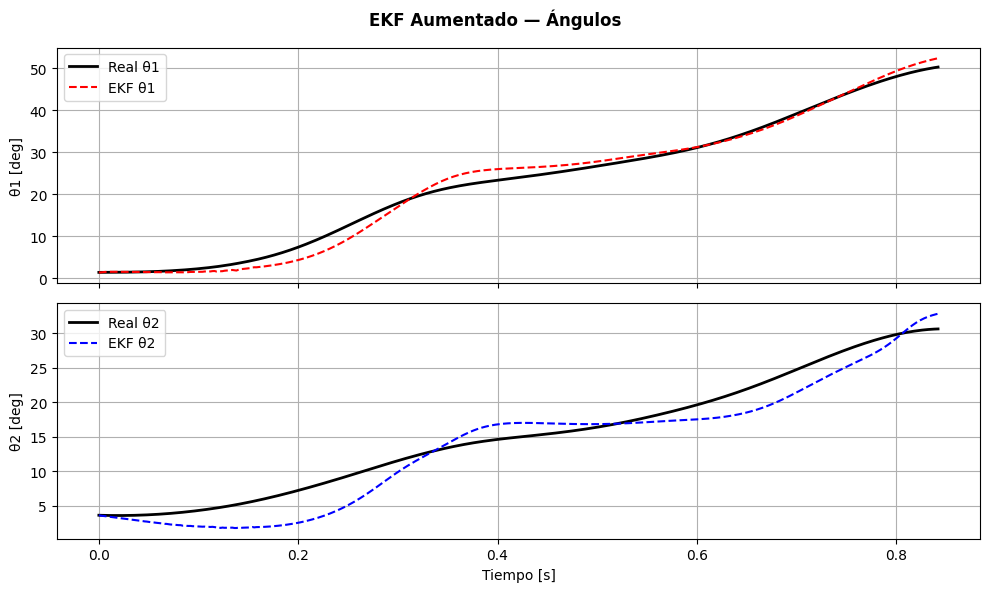

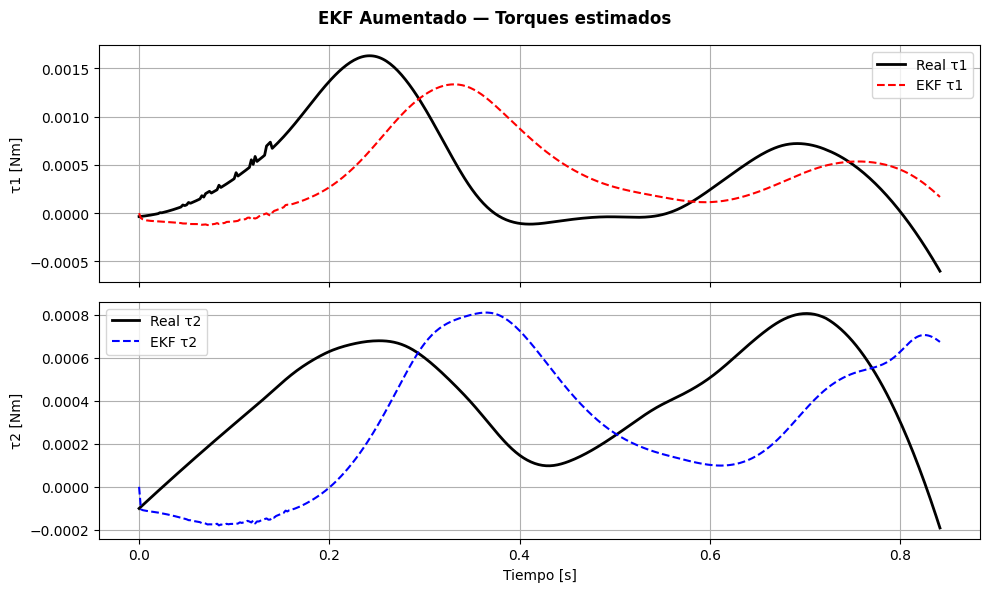

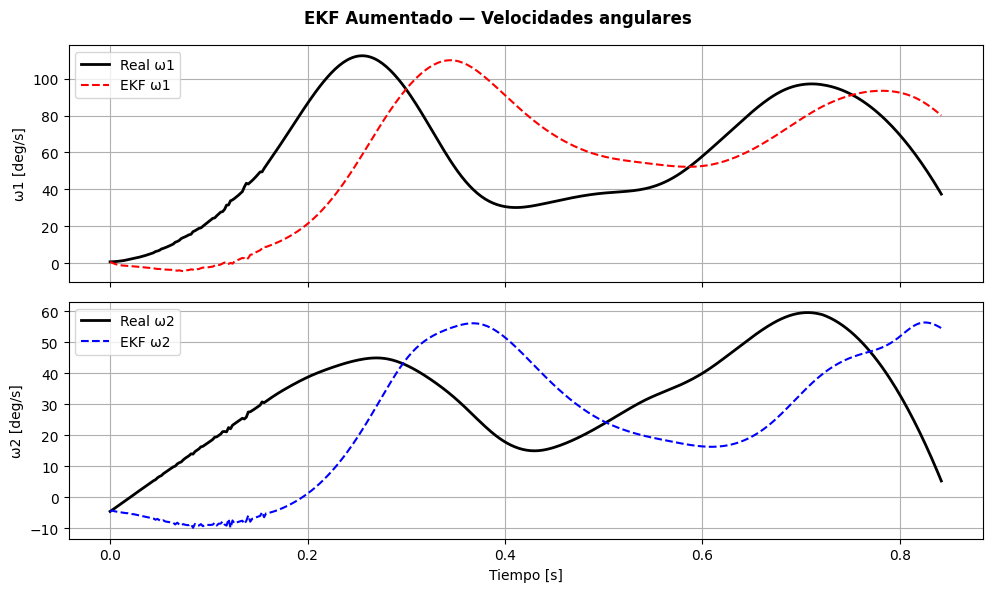

RMS error θ1: 1.623°
RMS error θ2: 2.512°


In [41]:
x_ekf_aug = np.array(x_hist_aug).squeeze()  # (N, 6)
x_true    = np.array([s.flatten() for s in true_states])

theta1_true = x_true[:,0];  omega1_true = x_true[:,1]
theta2_true = x_true[:,2];  omega2_true = x_true[:,3]

theta1_ekf = x_ekf_aug[:,0];  omega1_ekf = x_ekf_aug[:,1]
theta2_ekf = x_ekf_aug[:,2];  omega2_ekf = x_ekf_aug[:,3]
tau1_ekf   = x_ekf_aug[:,4];  tau2_ekf   = x_ekf_aug[:,5]

# Ángulos
fig, axs = plt.subplots(2, 1, figsize=(10,6), sharex=True)
axs[0].plot(t_array, np.rad2deg(theta1_true), 'k-', lw=2, label="Real θ1")
axs[0].plot(t_array, np.rad2deg(theta1_ekf),  'r--', label="EKF θ1")
axs[0].set_ylabel("θ1 [deg]"); axs[0].legend(); axs[0].grid(True)
axs[1].plot(t_array, np.rad2deg(theta2_true), 'k-', lw=2, label="Real θ2")
axs[1].plot(t_array, np.rad2deg(theta2_ekf),  'b--', label="EKF θ2")
axs[1].set_ylabel("θ2 [deg]"); axs[1].set_xlabel("Tiempo [s]")
axs[1].legend(); axs[1].grid(True)
plt.suptitle("EKF Aumentado — Ángulos", fontweight="bold")
plt.tight_layout(); plt.show()


# Torques estimados vs reales
fig, axs = plt.subplots(2, 1, figsize=(10,6), sharex=True)
axs[0].plot(t_array, torque_values[:,0], 'k-', lw=2, label="Real τ1")
axs[0].plot(t_array, tau1_ekf, 'r--', label="EKF τ1")
axs[0].set_ylabel("τ1 [Nm]"); axs[0].legend(); axs[0].grid(True)
axs[1].plot(t_array, torque_values[:,1], 'k-', lw=2, label="Real τ2")
axs[1].plot(t_array, tau2_ekf, 'b--', label="EKF τ2")
axs[1].set_ylabel("τ2 [Nm]"); axs[1].set_xlabel("Tiempo [s]")
axs[1].legend(); axs[1].grid(True)
plt.suptitle("EKF Aumentado — Torques estimados", fontweight="bold")
plt.tight_layout(); plt.show()

# Velocidades angulares
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].plot(t_array, np.rad2deg(omega1_true), 'k-', lw=2, label="Real ω1")
axs[0].plot(t_array, np.rad2deg(omega1_ekf),  'r--', label="EKF ω1")
axs[0].set_ylabel("ω1 [deg/s]"); axs[0].legend(); axs[0].grid(True)

axs[1].plot(t_array, np.rad2deg(omega2_true), 'k-', lw=2, label="Real ω2")
axs[1].plot(t_array, np.rad2deg(omega2_ekf),  'b--', label="EKF ω2")
axs[1].set_ylabel("ω2 [deg/s]"); axs[1].set_xlabel("Tiempo [s]")
axs[1].legend(); axs[1].grid(True)
plt.suptitle("EKF Aumentado — Velocidades angulares", fontweight="bold")
plt.tight_layout(); plt.show()


# RMS
rms_t1 = np.sqrt(np.mean((np.rad2deg(theta1_ekf) - np.rad2deg(theta1_true))**2))
rms_t2 = np.sqrt(np.mean((np.rad2deg(theta2_ekf) - np.rad2deg(theta2_true))**2))
print(f"RMS error θ1: {rms_t1:.3f}°")
print(f"RMS error θ2: {rms_t2:.3f}°")

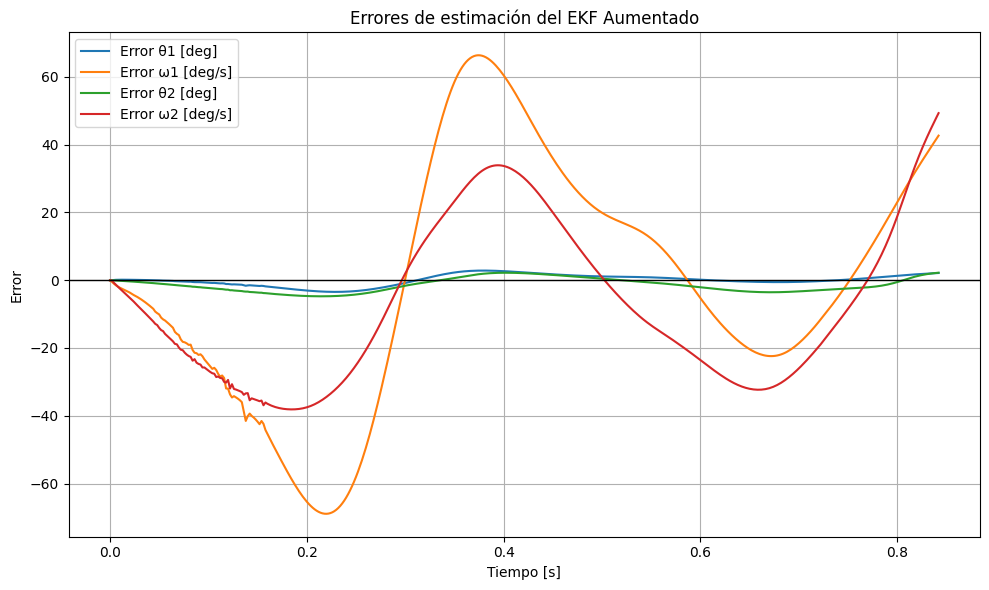

In [42]:
err = np.deg2rad(1) # solo para convertir unidades

# Errores en grados
err_theta1 = np.rad2deg(x_ekf_aug[:,0] - x_true[:,0])
err_omega1 = np.rad2deg(x_ekf_aug[:,1] - x_true[:,1])
err_theta2 = np.rad2deg(x_ekf_aug[:,2] - x_true[:,2])
err_omega2 = np.rad2deg(x_ekf_aug[:,3] - x_true[:,3])

errors = [err_theta1, err_omega1, err_theta2, err_omega2]
labels = ["θ1 [deg]", "ω1 [deg/s]", "θ2 [deg]", "ω2 [deg/s]"]

plt.figure(figsize=(10,6))
for i in range(4):
    plt.plot(t_array, errors[i], label=f"Error {labels[i]}")
plt.axhline(0, color='k', lw=1)
plt.xlabel("Tiempo [s]")
plt.ylabel("Error")
plt.title("Errores de estimación del EKF Aumentado")
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

In [38]:
#leave always as las cell
renderer.close()
mujoco.mj_resetData(model,data)
mujoco.mj_forward(model,data)